An idea came to me:

At equilibrium the correlation function is given as 

$$\braket{ \sigma \sigma} = C(r)$$

and we know that away from equilibriu mthe function takes a scale invariant form:

$$\braket{ \sigma \sigma  }= C(r) f( r/\xi)$$

Now then, we also have an understanding that this form is still somewhat accurate with quenches, eg. 

$$\braket{\sigma \sigma }=  C(r) f(r/\sqrt{\tau}) $$

is it then true that 

$$\rho  \dot{=} \braket{\sigma\sigma} - \braket{\sigma\sigma(\tau)}= C(r) (1-f(r/\sqrt{\tau}))=  C(1) ( 1- f(1/\sqrt{\tau}))?$$

If this is true, then we have a direct (!) connection between the structure factor and the kibble zurek effect.

What is a good way to test this? Presumably with the $$\sigma^x, \sigma^z$$ ops. 

In [111]:
import sys

sys.path.append("../../src")

from equilibrium_critical_correlations import sigma_general as sigma_x

from equilibrium_z_projectors import sigma_general as sigma_z

import kibble_zurek as kz

from common_imports import *

from numpy.fft import fft, fftfreq, fftshift
import kblock_ising_model as kb

import kibble_zurek as kz
import time
foldername = "Figures/"

def load_data():
    taus = np.load("data/tau_correlation_functions.npz")["b"]
    Y = np.load("data/tau_correlation_functions.npz")["a"]
    deltas = np.load("data/delta_correlation_functions.npz")["b"]
    X = np.load("data/delta_correlation_functions.npz")["a"]
    return deltas, X, taus, Y

In [101]:
r = np.arange(-100,100)
xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"
C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri])- sigma_z([0])**2 for ri in r])
# plt.figure(figsize=(8,6))
# plot(r,C_xx,label= xx_lab)
# plot(r,C_zz,label= zz_lab)
# plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
# plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
# legend()
# xlim(1,max(r))
# loglog()
# title("Equilibrium Connected Correlation Functions ")
# xlabel("r")

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [ ]:
###
#Ground State Generation
###
L = 500
k = kb.k_vals(L)
delta_values = np.logspace(-3,-1,25)

states = [kb.U(k,1+d) for d in delta_values]


In [ ]:
def xx(state,r):
#A function to just easily calculate the distance correlation functions
    return array([kb.sigma_general([0,i],state,k ) for i in tqdm(r)])

In [ ]:
X = [xx(state,r) for state in states]
#Takes around 15 minutes

  0%|          | 0/200 [00:00<?, ?it/s]/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 200/200 [00:35<00:00,  5.71it/s]


/tmp/ipykernel_5553/2408078838.py:4: RuntimeWarning: invalid value encountered in power
  scatter(r*d,((x)*r**(1/4)),label=str(d)[:6])


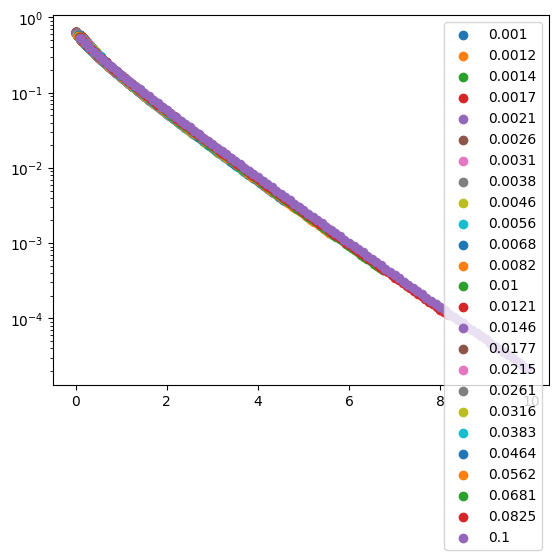

In [ ]:
#Scaling Collapse
for x,d in zip(X,delta_values):
    scatter(r*d,((x)*r**(1/4)),label=str(d)[:6])
legend()
yscale("log")

In [ ]:
###
# Kibble Zurek State Generation
###
L =500
taus = np.logspace(-2,3.5,20)
states = [kz.state(L,tau,0) for tau in taus]

In [ ]:
for i in range(len(states)):
    us, vs, k = states[i]
    us = np.array([complex(u) for u in us], dtype=np.complex128)
    vs = np.array([complex(v) for v in vs], dtype=np.complex128)
    k  = np.array(k, dtype=np.float64)
    states[i] = [us, vs, k]

In [10]:
def kxx(state,r):
    return array([kz.sigma_general([0,i],state) for i in r])

r = np.arange(-100,100)
Y = [kxx(state,r) for state in tqdm(states)]


  0%|          | 0/20 [00:00<?, ?it/s]/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:211: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 20/20 [03:21<00:00, 10.06s/it]


In [112]:
deltas, X, taus, Y = load_data()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/962216992.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


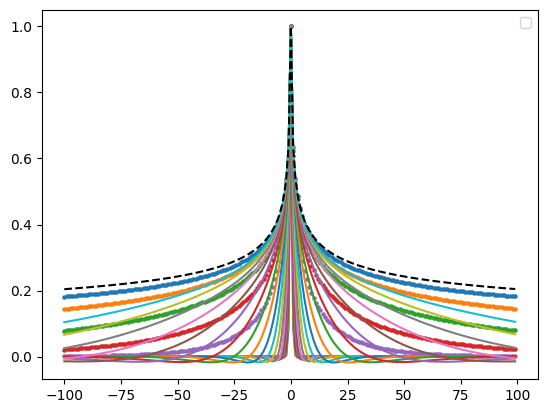

In [113]:
for y in Y:
    plot(r,y)
plot(r,C_xx,"--k")

for x in X[::5]:
     scatter(r,x,s=5)

legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/2968949489.py:3: RuntimeWarning: invalid value encountered in power
  plot(r/xi,abs(y*r**(1/4)),label=tau)


(1.0, 50.0)

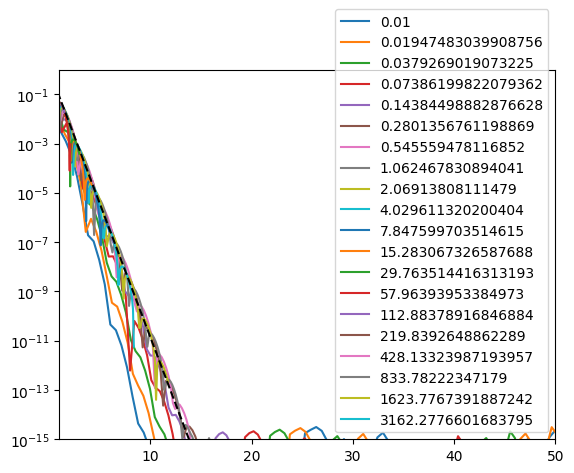

In [114]:
for y,tau,rho in zip(Y,taus,rhos):
    xi = 1/rho
    plot(r/xi,abs(y*r**(1/4)),label=tau)
legend()
plot(r,exp(-r*2.5),"--k")
#xscale('log')
ylim(0.000000000000001,1)
yscale('log')
xlim(1,50)

In [115]:
rhos = array([sigma_x([0,1])-kz.sigma_general([0,1],s) for s in states])

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:211: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


[]

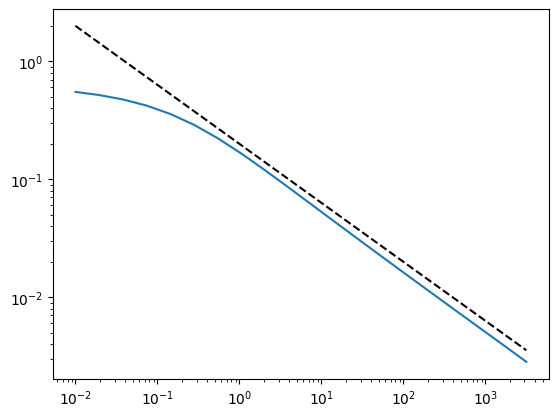

In [123]:
plot(taus,rhos)
plot(taus,taus**(-1/2)/sqrt(8*pi),"--k")
loglog()

In [116]:
#The players we have

X = array(X); #This is the correlation function vs delta

delta_values; # obviously the delta values

r; #Our distance variable

Y = array(Y); #the correlation functions with respect to quench time

taus; # The tau values 

rhos; #the actual defect densities as a function of tau




# Characterize the function C(r)

/tmp/ipykernel_5553/1957433944.py:8: RuntimeWarning: invalid value encountered in power
  axs[0,1].plot(r,x*r**(1/4),label="d")
/tmp/ipykernel_5553/1957433944.py:13: RuntimeWarning: invalid value encountered in power
  axs[1,0].plot(r*d,x*r**(1/4))
/tmp/ipykernel_5553/1957433944.py:17: RuntimeWarning: invalid value encountered in power
  axs[1,1].scatter(r*d,x*r**(1/4),s=5)


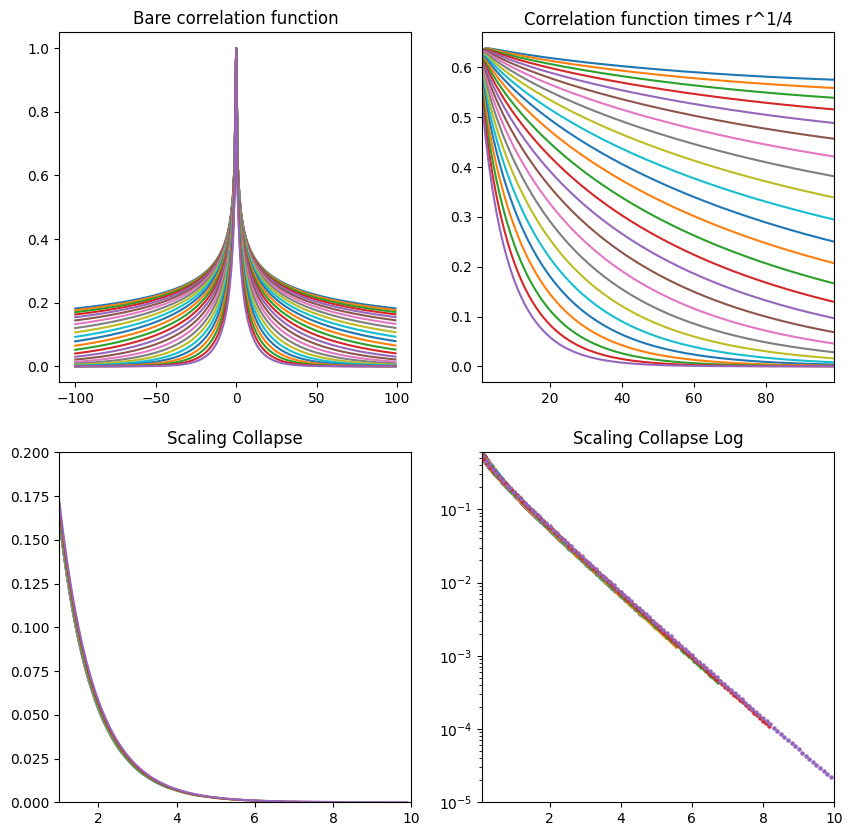

In [60]:
fig, axs = plt.subplots(2,2,figsize=(10,10))

for x ,d in zip(X,delta_values):
    axs[0,0].set_title("Bare correlation function")
    axs[0,0].plot(r,x,label=d);

    axs[0,1].set_title("Correlation function times r^1/4")
    axs[0,1].plot(r,x*r**(1/4),label="d")
    axs[0,1].set_xlim(1,r.max())
    #Scaling Collapse:

    axs[1,0].set_title("Scaling Collapse")
    axs[1,0].plot(r*d,x*r**(1/4))
    axs[1,0].set_xlim(1,10)
    axs[1,0].set_ylim(0,.2)
    axs[1,1].set_title("Scaling Collapse Log")
    axs[1,1].scatter(r*d,x*r**(1/4),s=5)
    axs[1,1].set_yscale("log")
    axs[1,1].set_xlim(.1,10)
    axs[1,1].set_ylim(0.00001,.6)
    #axs[0,0].legend()

Evidently the new function is a an exponential. Let's try fitting to determine its behaviour.

/tmp/ipykernel_5553/1735985976.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


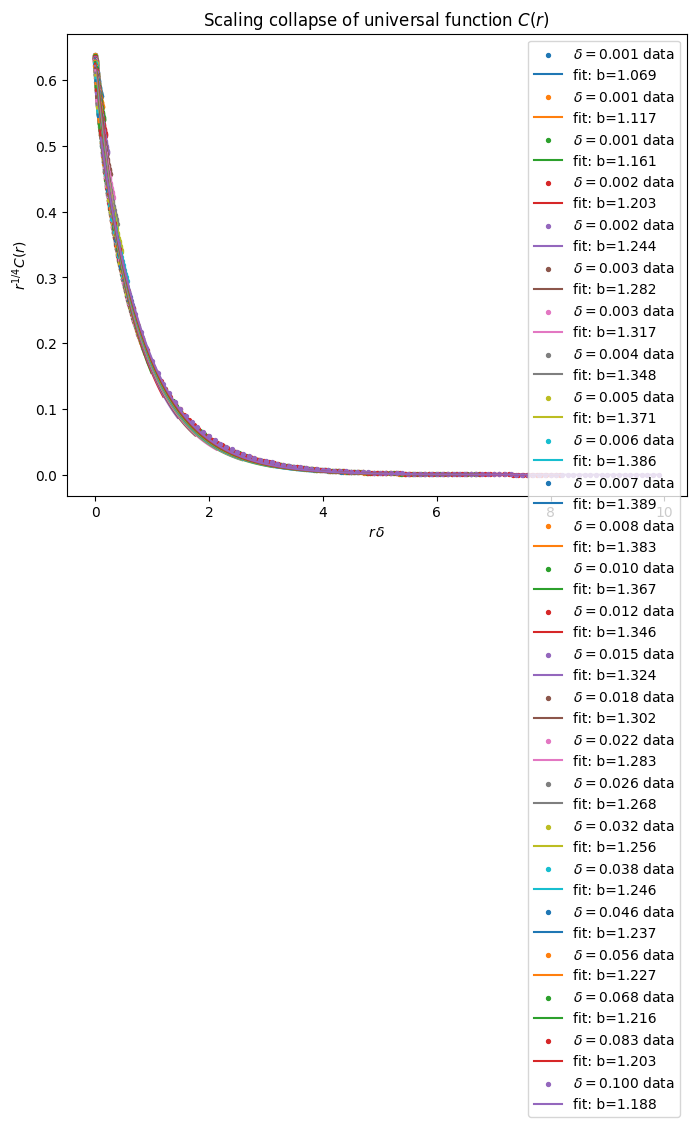

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit(x, a, b):
    return a * np.exp(-b * x)

plt.figure(figsize=(8,6))

for j in range(len(delta_values)):
    mask = r > 0
    xfit = r[mask] * abs(delta_values[j])
    yfit = X[j, mask] * r[mask]**(1/4)

    popt, _ = curve_fit(fit, xfit, yfit)
    a, b = popt

    plt.scatter(xfit, yfit, s=8, label=fr"$\delta={delta_values[j]:.3f}$ data")
    plt.plot(xfit, fit(xfit, a, b), '-', label=fr"fit: b={b:.3f}")

plt.xlabel(r"$r \, \delta$")
plt.ylabel(r"$r^{1/4} C(r)$")
plt.title("Scaling collapse of universal function $C(r)$")
plt.legend()
plt.tight_layout()
plt.show()


# Now we fit to an exponential

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: divide by zero encountered in matmul
  cov_x = invR @ invR.T
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:497: RuntimeWarning: invalid value encountered in matmul
  cov_x = invR @ invR.T


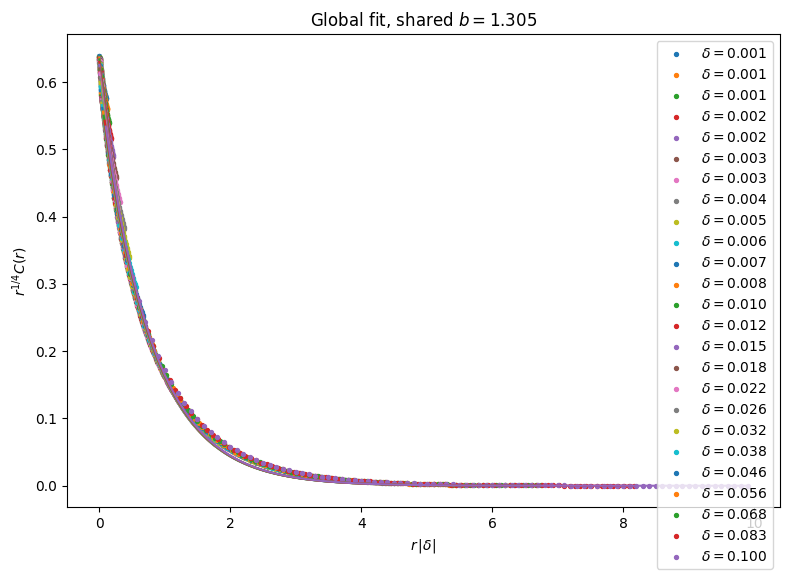

In [125]:

from scipy.optimize import curve_fit

def fit_global(all_x, *params):
    n = len(delta_values)
    a_list = params[:-1]
    b = params[-1]
    y = []
    for j in range(n):
        mask = r > 0
        xfit = r[mask] * np.abs(delta_values[j])
        y.append(a_list[j] * np.exp(-b * xfit))
    return np.concatenate(y)

# concatenate all data
x_all, y_all = [], []
for j in range(len(delta_values)):
    mask = r > 0
    xfit = r[mask] * np.abs(delta_values[j])
    yfit = X[j, mask] * r[mask]**(1/4)
    x_all.append(xfit)
    y_all.append(yfit)
x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)

# initial guesses: all a=1, b=1
p0 = [1.0]*len(delta_values) + [1.0]
popt, _ = curve_fit(fit_global, x_all, y_all, p0=p0)
a_list = popt[:-1]
b = popt[-1]

plt.figure(figsize=(8,6))
for j in range(len(delta_values)):
    mask = r > 0
    xfit = r[mask] * np.abs(delta_values[j])
    yfit = X[j, mask] * r[mask]**(1/4)
    plt.scatter(xfit, yfit, s=8, label=fr"$\delta={delta_values[j]:.3f}$")
    plt.plot(xfit, a_list[j] * np.exp(-b * xfit), '-')
plt.xlabel(r"$r\,|\delta|$")
plt.ylabel(r"$r^{1/4} C(r)$")
plt.title(fr"Global fit, shared $b={b:.3f}$")
plt.legend()
plt.tight_layout()
plt.show()


In [126]:
print(f"Shared decay constant b = {b:.6f}")


Shared decay constant b = 1.304521


# Characterize the function $C(r,\tau)$

A=0.6776, k=-0.3696, b=0.3714, phi=0.3944


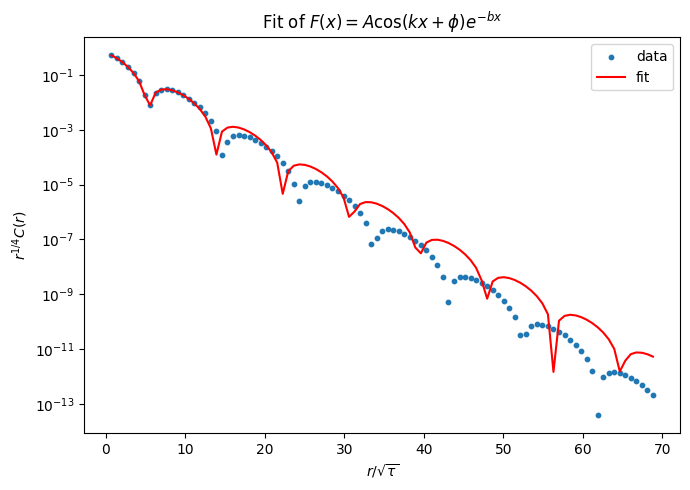

In [128]:
# define model: exponential decay with oscillations
def F_model(x, A, k, b, phi):
    return A * np.cos(k*abs(x) + phi) * np.exp(-b*abs(x))

# select first dataset
y = Y[8]
tau = taus[8]
mask = r > 0
xdata = r[mask] / np.sqrt(tau)
ydata = y[mask] * r[mask]**(1/4)
xtest = r[mask]/np.sqrt(taus[8])
# fit
p0 = [np.max(ydata), 1.0, 1.0, 0.0]
popt, _ = curve_fit(F_model, xdata, ydata, p0=p0, maxfev=10000)
A, k, b, phi = popt
print(f"A={A:.4f}, k={k:.4f}, b={b:.4f}, phi={phi:.4f}")

# plot
plt.figure(figsize=(7,5))
plt.scatter(xdata, abs(ydata), s=10, label="data")
plt.plot(xtest, abs(F_model(xtest, *popt)), 'r-', label="fit")
plt.xlabel(r"$r/\sqrt{\tau}$")
plt.ylabel(r"$r^{1/4} C(r)$")
plt.title(r"Fit of $F(x) = A\cos(kx+\phi)e^{-bx}$")
yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

The above cell tells us that the decay is a mix of an exponetial, and an oscilltiory cosine like function. The fit is not perfect! But it caputres the general important features well.

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/1571001879.py:9: RuntimeWarning: invalid value encountered in power
  axs[0,1].plot(r,y*r**(1/4),label="d")
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/1571001879.py:14: RuntimeWarning: invalid value encountered in power
  axs[1,0].scatter(r/(tau)**(1/2),y*r**(1/4))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/1571001879.py:18: RuntimeWarning: invalid value encountered in power
  axs[1,1].scatter(r/((tau)**(1/2)),abs(y*r**(1/4)),s=5)


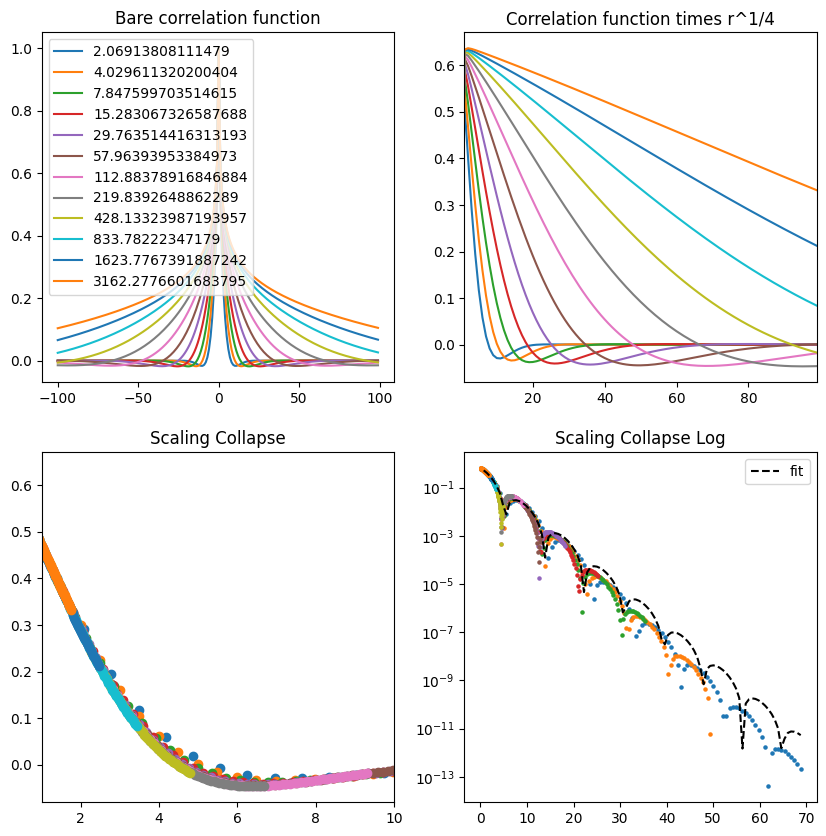

In [129]:
fig, axs = plt.subplots(2,2,figsize=(10,10))

for y ,tau,rho in zip(Y[8::1],taus[8::1],rhos[8::1]):
    xi = 1/rho
    axs[0,0].set_title("Bare correlation function")
    axs[0,0].plot(r,y,label=tau);

    axs[0,1].set_title("Correlation function times r^1/4")
    axs[0,1].plot(r,y*r**(1/4),label="d")
    axs[0,1].set_xlim(1,r.max())
    #Scaling Collapse:

    axs[1,0].set_title("Scaling Collapse")
    axs[1,0].scatter(r/(tau)**(1/2),y*r**(1/4))
    axs[1,0].set_xlim(1,10)
    #axs[1,0].set_ylim(0,.2)
    axs[1,1].set_title("Scaling Collapse Log")
    axs[1,1].scatter(r/((tau)**(1/2)),abs(y*r**(1/4)),s=5)
    axs[1,1].set_yscale("log")
    #axs[1,1].set_xlim(.1,10)
    #axs[1,1].set_ylim(0.00001,.6)
    axs[0,0].legend()
axs[1,1].plot(xtest, abs(F_model(xtest, *popt)), '--k', label="fit")

axs[1,1].legend()

foldername = "Figures/"

filename = "tau_scaling_collapse.png"
#plt.savefig(foldername+filename)

In [130]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# === Top row: equilibrium (delta) scaling collapse ===
for x, d in zip(X, delta_values):
    axs[0, 0].set_title("Equilibrium Scaling Collapse")
    axs[0, 0].plot(r * d, x * r**(1/4), label=f"{d:.3f}")
    axs[0, 0].set_xlim(1, 10)
    axs[0, 0].set_ylim(0, 0.2)

    axs[0, 1].set_title("Equilibrium Scaling Collapse (Log)")
    axs[0, 1].scatter(r * d, abs(x * r**(1/4)), s=5)
    axs[0, 1].set_yscale("log")A=0.6776, k=-0.3696, b=0.3714, phi=0.3944
au), abs(y * r**(1/4)), s=5)
    axs[1, 1].set_yscale("log")
    #axs[1, 1].set_xlim(1, 10)

axs[0, 0].legend(title=r"$\delta$")
axs[1, 0].legend(title=r"$\tau$")
plt.tight_layout()
plt.show()


SyntaxError: unmatched ')' (1266182878.py, line 13)

# Now let's look at the structure factor

In [131]:
from numpy.fft import fft, fftfreq, fftshift

In [132]:
k = fftshift(fftfreq(len(r),1))*2*pi

X_f = array([fftshift(fft(x)) for x in X])
Y_f = array([fftshift(fft(y)) for y in Y])

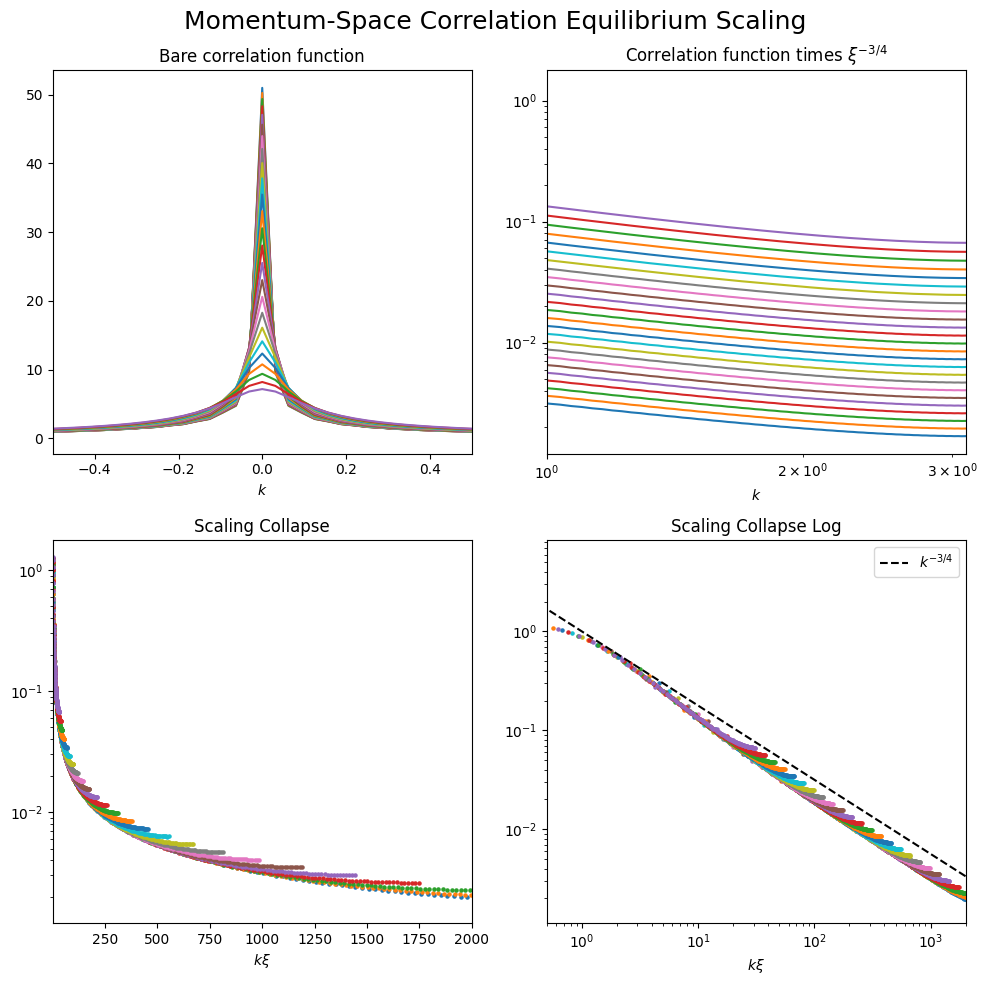

In [133]:


fig, axs = plt.subplots(2,2,figsize=(10,10))

for x ,d in zip(X_f,delta_values):
    xi = 1/d
    k_scaled = xi*k
    axs[0,0].set_title("Bare correlation function")
    axs[0,0].plot(k,abs(x),label=d);
    axs[0,0].set_xlim(-0.5,0.5)
    axs[0,1].set_title(r"Correlation function times $\xi^{-3/4}$")
    axs[0,1].plot(k,abs(x)*xi**(-3/4),label="d")
    axs[0,1].loglog()

    axs[0,1].set_xlim(1,k.max())
    #Scaling Collapse:

    axs[1,0].set_title("Scaling Collapse")
    axs[1,0].scatter(k_scaled,abs(x)*xi**(-3/4),s=5)
    axs[1,0].set_yscale("log")
    axs[1,0].set_xlim(0.5,2000)
    #axs[1,0].set_ylim(0,.2)
    axs[1,1].set_title("Scaling Collapse Log")
    axs[1,1].scatter(k_scaled,abs(x)*xi**(-3/4),s=5)
    axs[1,1].set_yscale("log")
    axs[1,1].set_xscale("log")
    axs[1,1].set_xlim(.5,2000)
    axs[1,1].set_xlabel(r"$k \xi$")
    axs[1,0].set_xlabel(r"$k \xi$")
    axs[0,1].set_xlabel(r"$k$")
    axs[0,0].set_xlabel(r"$k$")

    # axs[1,1].set_ylim(0.00001,.6)
    # #axs[0,0].legend()
kkk = np.logspace(-1,3.5)

axs[1,1].plot(kkk,kkk**(-3/4),"--k",label=r"$k^{-3/4}$")
axs[1,1].legend()
fig.suptitle("Momentum-Space Correlation Equilibrium Scaling", fontsize=18)
plt.tight_layout()
plt.savefig(foldername+"delta_momentumspace_correlation_scaling.png")

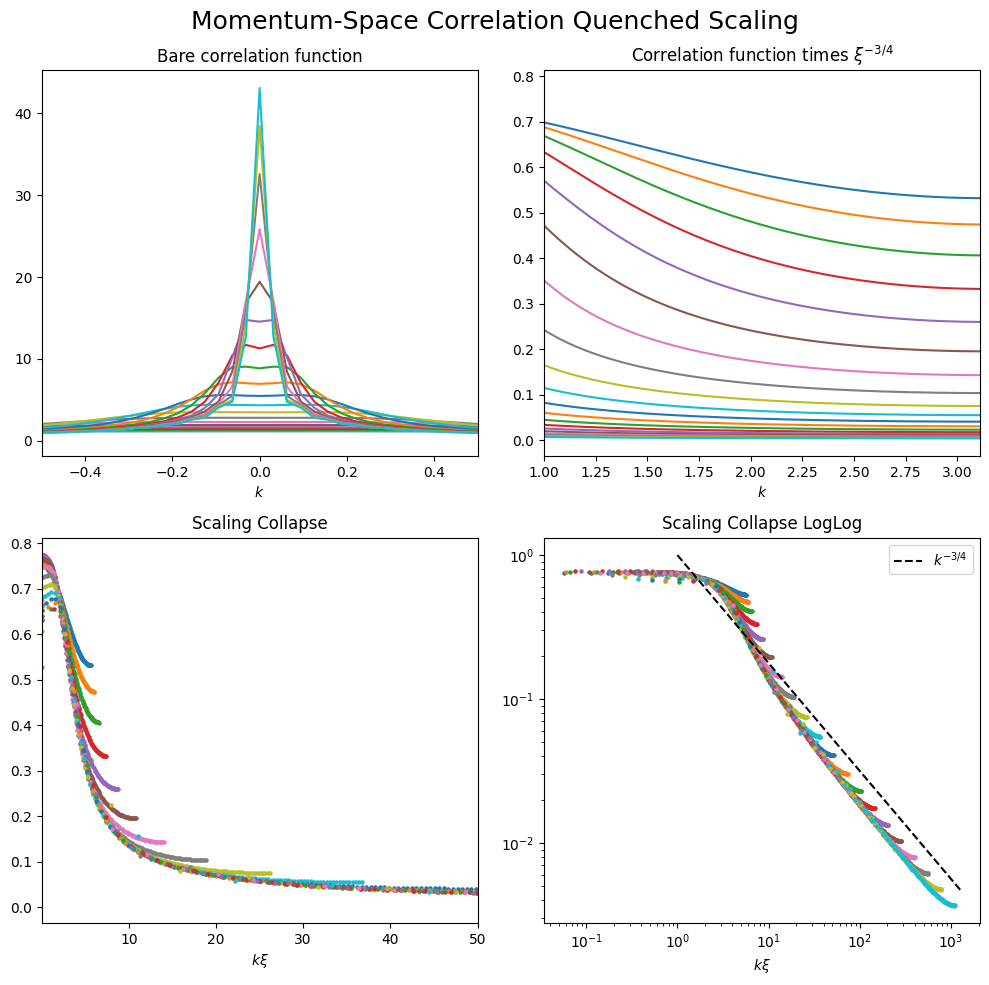

In [134]:


fig, axs = plt.subplots(2,2,figsize=(10,10))

for y ,tau,rho in zip(Y_f,taus,rhos):
    axs[0,0].set_title("Bare correlation function")
    xi = 1/rho
    k_scaled = k*xi
    axs[0,0].plot(k,abs(y),label=d);
    axs[0,0].set_xlim(-0.5,0.5)
    
    axs[0,1].set_title(r"Correlation function times $\xi^{-3/4}$")
    axs[0,1].plot(k,abs(y)*xi**(-3/4),label="d")
    axs[0,1].set_xlabel(r"$k $")

    #axs[0,1].loglog()

    axs[0,1].set_xlim(1,k.max())
    #Scaling Collapse:

    axs[1,0].set_title("Scaling Collapse")
    axs[1,0].scatter(k_scaled,abs(y)*xi**(-3/4),s=5)
    axs[1,0].set_xlim(0.01,50)
    axs[1,0].set_xlabel(r"$k \xi$")
    axs[1,1].set_title("Scaling Collapse LogLog")
    axs[1,1].scatter(k_scaled,abs(y)*xi**(-3/4),s=5)
    axs[1,1].loglog()
   # axs[1,1].set_xlim(0.01,50)
    axs[1,1].set_xlabel(r"$k \xi$")
    axs[0,0].set_xlabel(r"$k $")

    # #axs[1,0].set_ylim(0,.2)
    # axs[1,1].set_title("Scaling Collapse Log")
    # axs[1,1].scatter(k*d,x*k**(1/4),s=5)
    #axs[1,0].set_yscale("log")
    # axs[1,1].set_xlim(.1,10)
    # axs[1,1].set_ylim(0.00001,.6)
    # #axs[0,0].legend()
fake_k = np.logspace(0,3.1,100)
axs[1,1].plot(fake_k,fake_k**(-3/4),"--k",label=r"$k^{-3/4}$")
axs[1,1].legend()
fig.suptitle("Momentum-Space Correlation Quenched Scaling", fontsize=18)
plt.tight_layout()
plt.savefig(foldername+"tau_momentumspace_correlation_scaling.png")

# Now we will fourier transform our ansatz for the quenched universal function, and see if we can recreate this caling factor

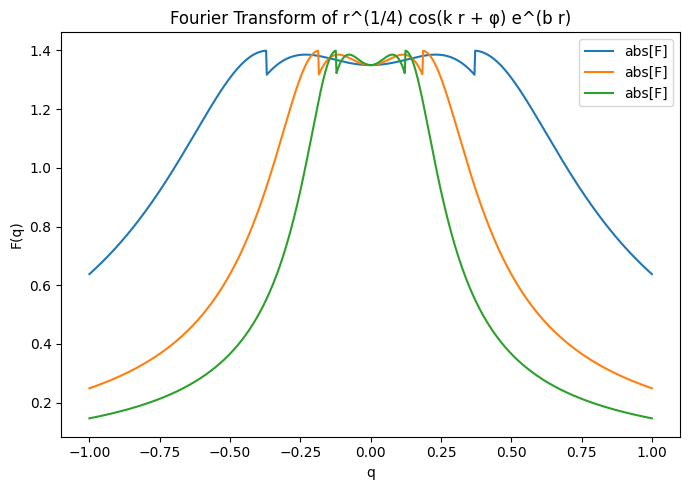

In [135]:
from scipy.special import gamma

def FT_Sardine(q, A=0.6776, k=-0.3696, b=0.3714, phi=0.3944):
    """
    Fourier transform of r^(1/4) * cos(k*r + phi) * exp(b*r)
    for Re(b) < 0.
    """
    q = np.asarray(q, dtype=np.complex128)
    G = gamma(5/4)
    term1 = np.exp(1j * phi) * (-b - 1j * (q - k))**(-5/4)
    term2 = np.exp(-1j * phi) * (-b - 1j * (q + k))**(-5/4)
    return A * 0.5 * G * (term1 + term2)

# Sardine vector and plot
Sardine = np.linspace(-1, 1, 800)

plt.figure(figsize=(7,5))
Fvals = FT_Sardine(Sardine*1)

plt.plot(Sardine, abs(Fvals), label="abs[F]")
Fvals = FT_Sardine(Sardine*2)

plt.plot(Sardine, abs(Fvals), label="abs[F]")
Fvals = FT_Sardine(Sardine*3)

plt.plot(Sardine, abs(Fvals), label="abs[F]")
plt.xlabel("q")
plt.ylabel("F(q)")
plt.title("Fourier Transform of r^(1/4) cos(k r + φ) e^(b r)")
plt.legend()
plt.tight_layout()
plt.show()


In [139]:
def F_model(x, A=0.6776, k=-0.3696, b=0.3714, phi=0.3944):
    return A * np.cos(k*x + phi) * np.exp(-b*x)


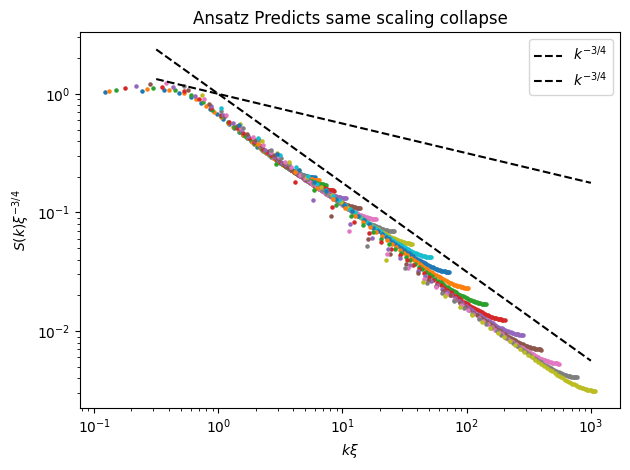

In [202]:
testr = np.arange(1, 101)
testr = testr[testr != 0]
ktest = fftshift(fftfreq(len(testr), testr[1]-testr[0])) * 2*pi

for tau, rho in zip(taus[1::1], rhos[1::1]):
    xi = 1 / rho
    GGG = F_model(testr * rho) * abs(testr)**(-1/4)
    GGG = abs(fftshift(fft(GGG)))
    plt.scatter(ktest * xi, GGG * xi**(-3/4), s=5)#, label=rf"$\tau={tau}$")

title("Ansatz Predicts same scaling collapse")
kkk = np.logspace(-0.5,3,100)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k\xi$")
plt.ylabel(r"$S(k)\xi^{-3/4}$")
plt.plot(kkk,kkk**(-3/4),"--k",label=r"$k^{-3/4}$")
plt.plot(kkk,kkk**(-1/4),"--k",label=r"$k^{-3/4}$")

plt.tight_layout()
legend()

plt.show()


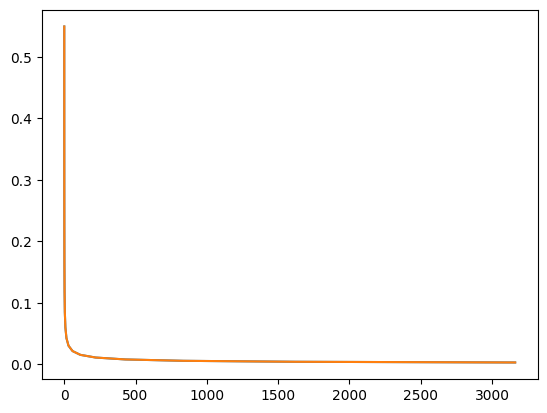

In [160]:
gg= []
for i in range(len(Y)):
   gg+=[((C_xx-Y[i])[r==1])]

plot(taus,gg)
plot(taus,rhos)

Now, we will see if we can connect it to the kible Zurek Effect

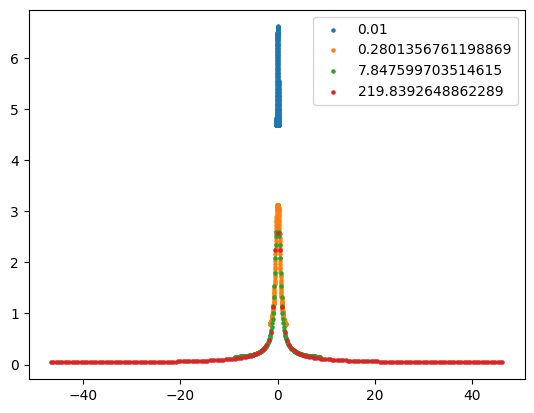

In [220]:
for tau,y in zip(taus[::5],Y[::5]):
    xi = sqrt(tau)


    k_rescale = k*xi
    G_f = fftshift(fft(y))

    scatter(k_rescale,abs(G_f)*xi**(-3/4),s=5,label=tau)
legend()

In [ ]:
taus = np.load("data/tau_correlation_functions.npz")["b"]
Y = np.load("data/tau_correlation_functions.npz")["a"]
deltas = np.load("data/delta_correlation_functions.npz")["b"]
X = np.load("data/delta_correlation_functions.npz")["a"]

array([1.00000000e-02, 1.94748304e-02, 3.79269019e-02, 7.38619982e-02,
       1.43844989e-01, 2.80135676e-01, 5.45559478e-01, 1.06246783e+00,
       2.06913808e+00, 4.02961132e+00, 7.84759970e+00, 1.52830673e+01,
       2.97635144e+01, 5.79639395e+01, 1.12883789e+02, 2.19839265e+02,
       4.28133240e+02, 8.33782223e+02, 1.62377674e+03, 3.16227766e+03])

In [110]:
np.load("data/delta_correlation_functions.npz")["b"]

array([0.001     , 0.00121153, 0.0014678 , 0.00177828, 0.00215443,
       0.00261016, 0.00316228, 0.00383119, 0.00464159, 0.00562341,
       0.00681292, 0.00825404, 0.01      , 0.01211528, 0.01467799,
       0.01778279, 0.02154435, 0.02610157, 0.03162278, 0.03831187,
       0.04641589, 0.05623413, 0.06812921, 0.08254042, 0.1       ])

In [227]:
tau2 =np.logspace(-2,2.5,50)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/4127156329.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


[]

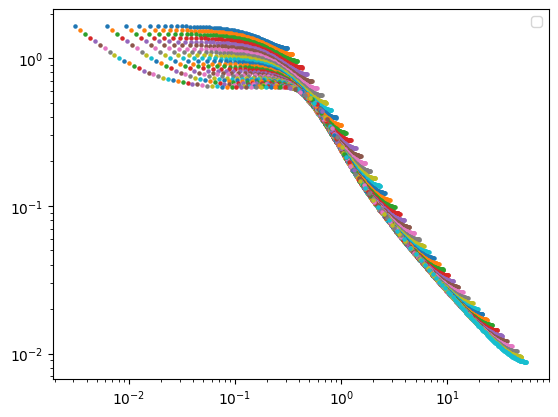

In [250]:
g = np.load("data/PP_n1_4.npy")[0]

for i,tau in zip(g[::1],tau2[::1]):
    f = fftshift(fft(i))
    scatter(k*sqrt(tau),abs(f)*sqrt(tau)**(-3/4),s=5)

legend()
loglog()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/2689085035.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


[]

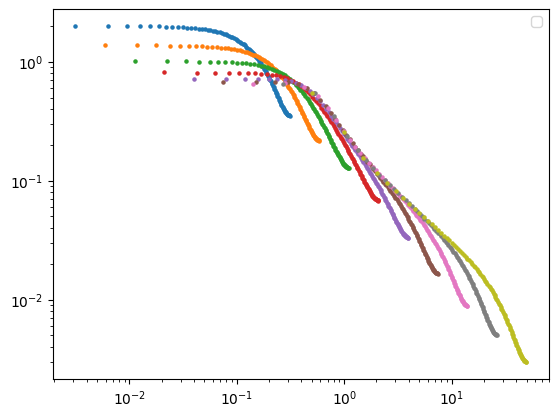

In [252]:
g = np.load("data/PP_n1_4.npy")[1]

for i,tau in zip(g[::6],tau2[::6]):
    f = fftshift(fft(i))
    scatter(k*sqrt(tau),abs(f)*sqrt(tau)**(-3/4),s=5)

legend()
loglog()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/1178368505.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


[]

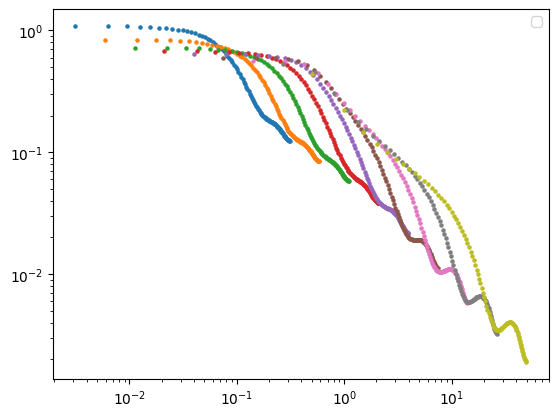

In [253]:
g = np.load("data/PP_n1_4.npy")[-1]

for i,tau in zip(g[::6],tau2[::6]):
    f = fftshift(fft(i))
    scatter(k*sqrt(tau),abs(f)*sqrt(tau)**(-3/4),s=5)

legend()
loglog()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/350991819.py:4: RuntimeWarning: invalid value encountered in power
  scatter(r,i*r**(1/4),s=5)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/350991819.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()


(0.0, 100.0)

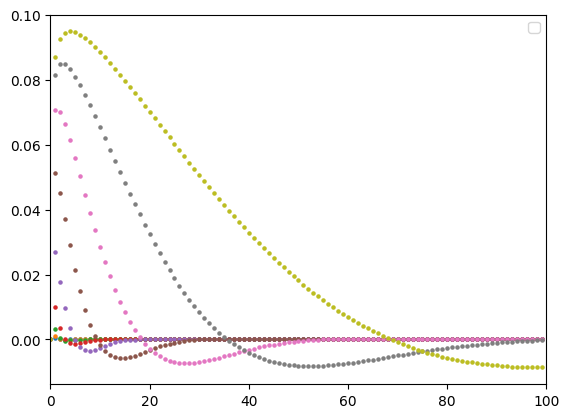

In [264]:
g = np.load("data/PP_n1_4.npy")[-1]

for i,tau in zip(g[::6],tau2[::6]):
    scatter(r,i*r**(1/4),s=5)

legend()
xlim(0,100)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/2348500530.py:4: RuntimeWarning: invalid value encountered in power
  scatter(r,i*r**(1/4),s=5)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/2348500530.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend()
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_48513/2348500530.py:11: RuntimeWarning: invalid value encountered in power
  plot(r,i*r**(1/4)/1.5)


(1.0, 100.0)

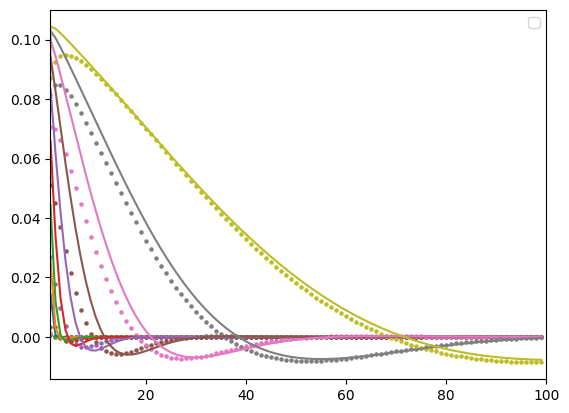

In [289]:
g = np.load("data/PP_n1_4.npy")[-1]

for i,tau in zip(g[::6],tau2[::6]):
    scatter(r,i*r**(1/4),s=5)

legend()
xlim(0,100)
g = np.load("data/PP_n1_4.npy")[0]

for i,tau in zip(g[::6],tau2[::6]):
    plot(r,i*r**(1/4)/1.5)

# plot(r,0.25*F_model(abs(r/sqrt(tau2[-1]))))
# legend()
xlim(1,100)